# Metrics Over Epochs

Plots validation metric histories from saved metric JSON files.

In [1]:
import os
from pathlib import Path

# Ensure project root is on path when running from examples/.
notebook_dir = Path().absolute()
if notebook_dir.name == "examples":
    os.chdir(notebook_dir.parent)

import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
import matplotlib.ticker as mticker

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "no-latex"])
except Exception:
    pass

from examples.postprocess import _EPOCH_METRICS, _load_model_stores, _smooth


## Configuration

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
DATASET_TYPE   = "ts_young"                # "ts_young" or "lsd"
METRICS_DIR    = "results/metrics"    # directory with per-model metric JSON files
SMOOTH_WINDOW  = 5                    # moving-average window (1 = no smoothing)
FIGSIZE_GRID   = (15, 12)             # (width, height) of the all-metrics grid figure
FIGSIZE_SPLIT  = (8, 4)              # (width, height) of the loss | 3x3 split figure

# Edit this list to choose which models appear in the plots, in this order.
MODELS_TO_PLOT = ["Hopf", "Hybrid Hopf", "Neural SDE"]


def _filter_model_stores(model_stores, models_to_plot):
    if not models_to_plot:
        return model_stores

    missing = [label for label in models_to_plot if label not in model_stores]
    if missing:
        print(f"Missing requested model(s): {missing}")
        print(f"Available model(s): {list(model_stores)}")

    return {label: model_stores[label] for label in models_to_plot if label in model_stores}


model_stores = _load_model_stores(DATASET_TYPE, METRICS_DIR)
model_stores = _filter_model_stores(model_stores, MODELS_TO_PLOT)
colors = plt.cm.tab10.colors

print(f"Plotting {len(model_stores)} model(s): {list(model_stores)}")


Missing requested model(s): ['Hopf', 'Hybrid Hopf', 'Neural SDE']
Available model(s): []
Plotting 0 model(s): []


In [3]:
%matplotlib inline

## All Metrics Grid

/tmp/ipykernel_187736/617856258.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


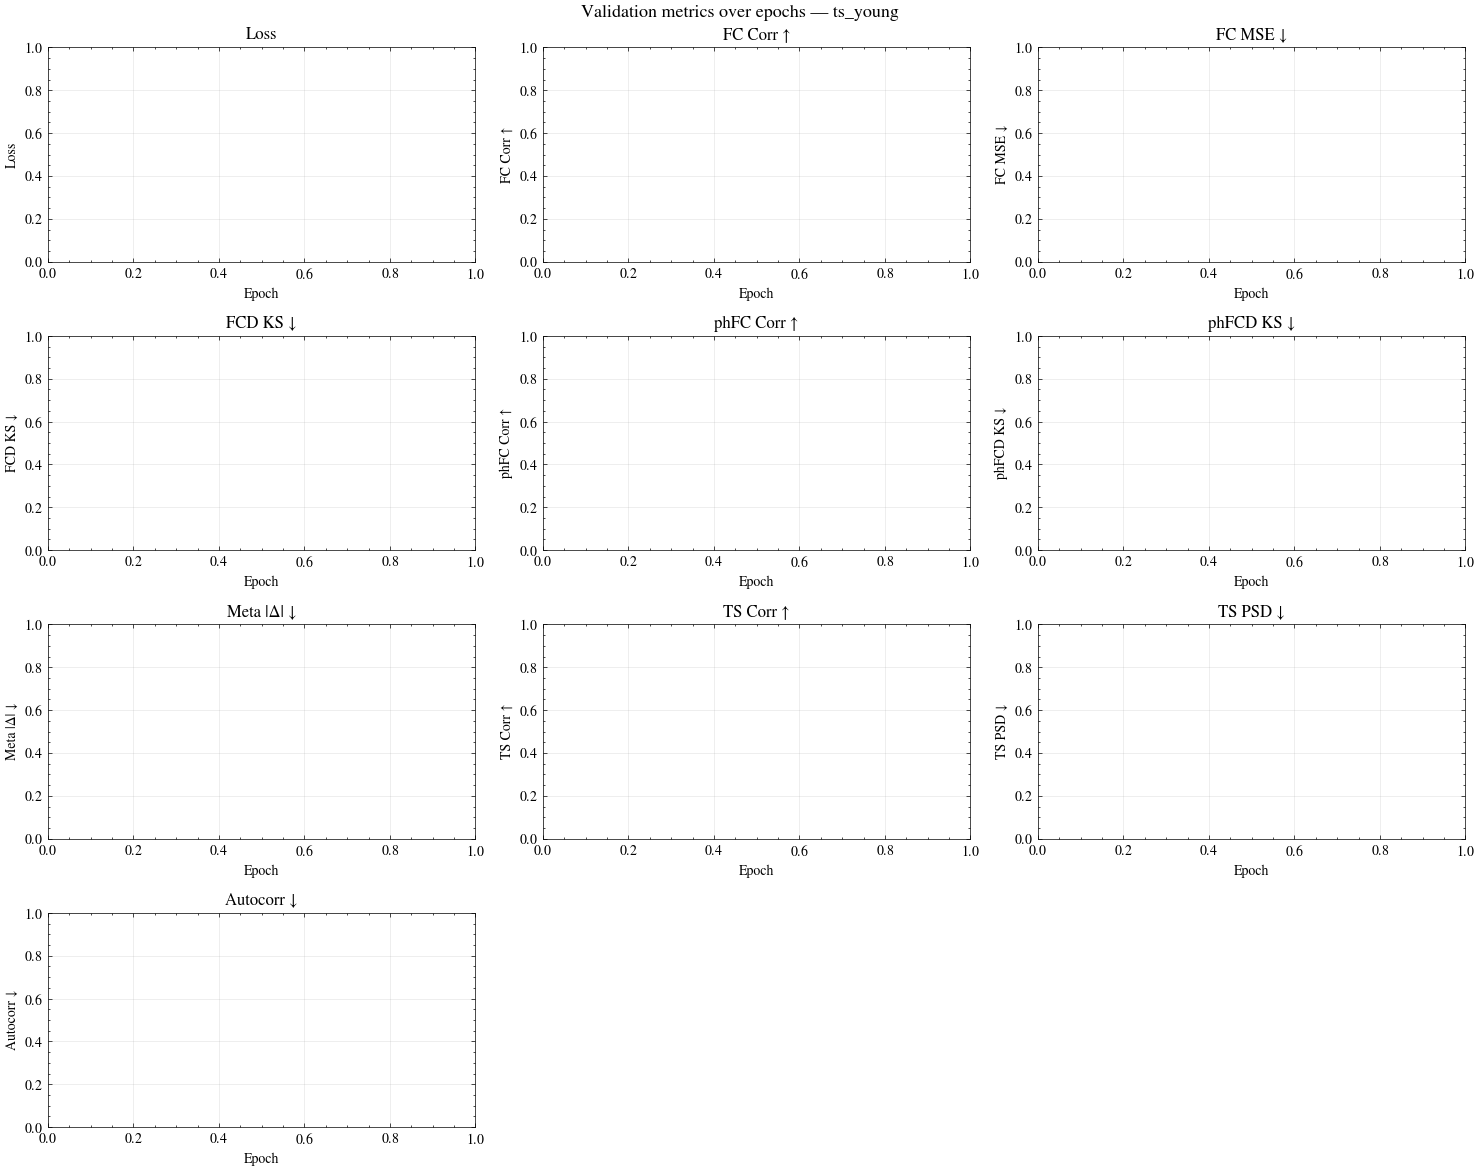

In [4]:
# ── Figure 1: all-metrics grid ────────────────────────────────────────────────
n_cols = 3
n_rows = math.ceil(len(_EPOCH_METRICS) / n_cols)
fig1, axes = plt.subplots(n_rows, n_cols, figsize=FIGSIZE_GRID)
axes_flat = axes.flatten()

for ax_idx, (mkey, mlabel) in enumerate(_EPOCH_METRICS):
    ax = axes_flat[ax_idx]
    has_data, all_pos = False, True
    for ci, (label, store) in enumerate(model_stores.items()):
        val_vals = store.get_metric_history(mkey, "val")
        if not val_vals:
            continue
        epochs = [e["epoch"] for e in store.val_metrics if mkey in e]
        clean = [(ep, v) for ep, v in zip(epochs, val_vals) if v is not None and not math.isnan(v)]
        if not clean:
            continue
        ep_arr, v_arr = zip(*clean)
        color = colors[ci % len(colors)]
        ax.plot(ep_arr, v_arr, color=color, linewidth=0.8, alpha=0.25)
        ax.plot(ep_arr, _smooth(list(v_arr), SMOOTH_WINDOW), label=label, color=color, linewidth=1.8)
        has_data = True
        if any(v <= 0 for v in v_arr):
            all_pos = False
    ax.set_xlabel("Epoch")
    ax.set_ylabel(mlabel)
    ax.set_title(mlabel)
    ax.grid(True, alpha=0.3)
    if ax_idx == 0:
        ax.legend(fontsize=7)
    if has_data and all_pos:
        ax.set_yscale("log")

for ax_idx in range(len(_EPOCH_METRICS), len(axes_flat)):
    axes_flat[ax_idx].set_visible(False)

plt.suptitle(f"Validation metrics over epochs — {DATASET_TYPE}", fontsize=13)
plt.tight_layout()

for out_dir in [
    Path("paper_new/images") / DATASET_TYPE,
    Path("paper_new/images_png") / DATASET_TYPE,
    Path("paper_new/images_svg") / DATASET_TYPE,
]:
    out_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(Path("paper_new/images") / DATASET_TYPE / "metrics_over_epochs.pdf", bbox_inches="tight", dpi=150)
plt.savefig(Path("paper_new/images_png") / DATASET_TYPE / "metrics_over_epochs.png", bbox_inches="tight", dpi=200)
plt.savefig(Path("paper_new/images_svg") / DATASET_TYPE / "metrics_over_epochs.svg", bbox_inches="tight")
plt.show()


## Loss Plus Metric Panels

/tmp/ipykernel_187736/3848253637.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_loss.legend(fontsize=10)


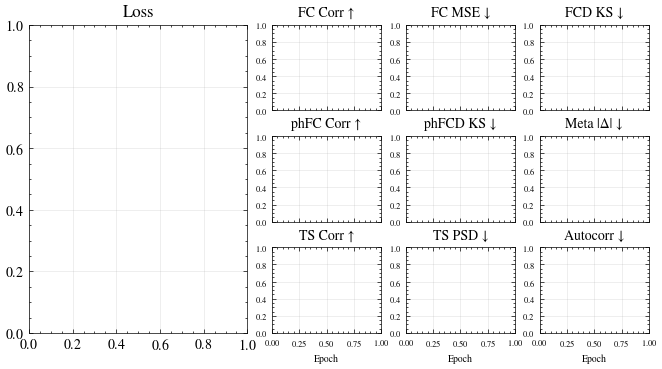

In [5]:
# ── Figure 2: loss plot plus 3x3 metrics grid ────────────────────────────────
other_metrics = _EPOCH_METRICS[1:10]
FC_MODEL_COLORS = {
    "Hopf": "#DD8452",        # salmon
    "Neural SDE": "#4C72B0",  # blue
    "Hybrid Hopf": "#55A868", # green
}
fig2 = plt.figure(figsize=FIGSIZE_SPLIT)
gs = mgridspec.GridSpec(3, 4, figure=fig2, width_ratios=[2, 1, 1, 1], hspace=0.3, wspace=0.18)

ax_loss = fig2.add_subplot(gs[:, 0])
has_data_loss, all_pos_loss = False, True
for ci, (label, store) in enumerate(model_stores.items()):
    val_vals = store.get_metric_history("loss", "val")
    if not val_vals:
        continue
    epochs = [e["epoch"] for e in store.val_metrics if "loss" in e]
    clean = [(ep, v) for ep, v in zip(epochs, val_vals) if v is not None and not math.isnan(v)]
    if not clean:
        continue
    ep_arr, v_arr = zip(*clean)
    color = FC_MODEL_COLORS.get(label)
    ax_loss.plot(ep_arr, v_arr, color=color, linewidth=0.8, alpha=0.25)
    ax_loss.plot(ep_arr, _smooth(list(v_arr), SMOOTH_WINDOW), label=label, color=color, linewidth=2.0)
    ax_loss.set_xlabel("Epoch", fontsize=7)
    has_data_loss = True
    if any(v <= 0 for v in v_arr):
        all_pos_loss = False

#ax_loss.set_ylabel("Loss")
ax_loss.set_title("Loss", fontsize=12)
ax_loss.grid(True, alpha=0.3)
ax_loss.legend(fontsize=10)
if has_data_loss and all_pos_loss:
    ax_loss.set_yscale("log")

for idx, (mkey, mlabel) in enumerate(other_metrics):
    row, col = idx // 3, 1 + (idx % 3)
    ax = fig2.add_subplot(gs[row, col])
    has_data, all_pos = False, True
    for ci, (label, store) in enumerate(model_stores.items()):
        val_vals = store.get_metric_history(mkey, "val")
        if not val_vals:
            continue
        epochs = [e["epoch"] for e in store.val_metrics if mkey in e]
        clean = [(ep, v) for ep, v in zip(epochs, val_vals) if v is not None and not math.isnan(v)]
        if not clean:
            continue
        ep_arr, v_arr = zip(*clean)
        color = FC_MODEL_COLORS.get(label)
        ax.plot(ep_arr, v_arr, color=color, linewidth=0.8, alpha=0.25)
        ax.plot(ep_arr, _smooth(list(v_arr), SMOOTH_WINDOW), color=color, linewidth=1.5)
        has_data = True
        if any(v <= 0 for v in v_arr):
            all_pos = False
    if row == 2:
        ax.set_xlabel("Epoch", fontsize=7)
    else:
        ax.set_xticklabels([])
    ax.set_title(mlabel, fontsize=10)
    ax.grid(True, alpha=0.3)
    if has_data and all_pos:
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
        ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis="y", which="major", labelsize=6)
    ax.tick_params(axis="x", which="major", labelsize=6)

#plt.suptitle(f"Validation metrics over epochs — {DATASET_TYPE}", fontsize=13)
plt.savefig(Path("paper_new/images") / DATASET_TYPE / "metrics_over_epochs_split.pdf", bbox_inches="tight", dpi=150)
plt.savefig(Path("paper_new/images_png") / DATASET_TYPE / "metrics_over_epochs_split.png", bbox_inches="tight", dpi=200)
plt.savefig(Path("paper_new/images_svg") / DATASET_TYPE / "metrics_over_epochs_split.svg", bbox_inches="tight")
plt.show()


/tmp/ipykernel_187736/955260672.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_loss.legend(fontsize=10)


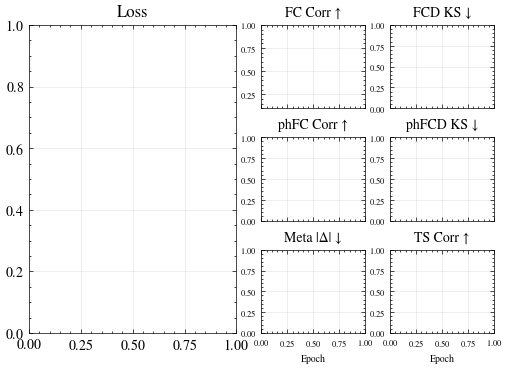

In [6]:
# ── Figure 3: loss plot plus 3x2 metrics grid (excludes TS PSD, Autocorr, FC MSE) ──
EXCLUDED_METRICS = {"fc_mse", "power_spectrum_distance", "autocorr_distance"}
other_metrics_filtered = [
    (mkey, mlabel) for (mkey, mlabel) in _EPOCH_METRICS[1:]
    if mkey not in EXCLUDED_METRICS
]

FC_MODEL_COLORS = {
    "Hopf": "#DD8452",        # salmon
    "Neural SDE": "#4C72B0",  # blue
    "Hybrid Hopf": "#55A868", # green
}

FIGSIZE_SPLIT_REDUCED = (6, 4)
fig3 = plt.figure(figsize=FIGSIZE_SPLIT_REDUCED)
gs = mgridspec.GridSpec(3, 3, figure=fig3, width_ratios=[2, 1, 1], hspace=0.35, wspace=0.18)

ax_loss = fig3.add_subplot(gs[:, 0])
has_data_loss, all_pos_loss = False, True
for ci, (label, store) in enumerate(model_stores.items()):
    val_vals = store.get_metric_history("loss", "val")
    if not val_vals:
        continue
    epochs = [e["epoch"] for e in store.val_metrics if "loss" in e]
    clean = [(ep, v) for ep, v in zip(epochs, val_vals) if v is not None and not math.isnan(v)]
    if not clean:
        continue
    ep_arr, v_arr = zip(*clean)
    color = FC_MODEL_COLORS.get(label)
    ax_loss.plot(ep_arr, v_arr, color=color, linewidth=0.8, alpha=0.25)
    ax_loss.plot(ep_arr, _smooth(list(v_arr), SMOOTH_WINDOW), label=label, color=color, linewidth=2.0)
    ax_loss.set_xlabel("Epoch", fontsize=7)
    has_data_loss = True
    if any(v <= 0 for v in v_arr):
        all_pos_loss = False

ax_loss.set_title("Loss", fontsize=12)
ax_loss.grid(True, alpha=0.3)
ax_loss.legend(fontsize=10)
if has_data_loss and all_pos_loss:
    ax_loss.set_yscale("log")

for idx, (mkey, mlabel) in enumerate(other_metrics_filtered):
    row, col = idx // 2, 1 + (idx % 2)
    ax = fig3.add_subplot(gs[row, col])
    has_data, all_pos = False, True
    for ci, (label, store) in enumerate(model_stores.items()):
        val_vals = store.get_metric_history(mkey, "val")
        if not val_vals:
            continue
        epochs = [e["epoch"] for e in store.val_metrics if mkey in e]
        clean = [(ep, v) for ep, v in zip(epochs, val_vals) if v is not None and not math.isnan(v)]
        if not clean:
            continue
        ep_arr, v_arr = zip(*clean)
        color = FC_MODEL_COLORS.get(label)
        ax.plot(ep_arr, v_arr, color=color, linewidth=0.8, alpha=0.25)
        ax.plot(ep_arr, _smooth(list(v_arr), SMOOTH_WINDOW), color=color, linewidth=1.5)
        has_data = True
        if any(v <= 0 for v in v_arr):
            all_pos = False
    if idx==0:
        ax.set_ylim(bottom=0.1)
    if row == 2:
        ax.set_xlabel("Epoch", fontsize=7)
    else:
        ax.set_xticklabels([])
    ax.set_title(mlabel, fontsize=10)
    ax.grid(True, alpha=0.3)
    if has_data and all_pos:
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
        ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis="y", which="major", labelsize=6)
    ax.tick_params(axis="x", which="major", labelsize=6)

plt.savefig(Path("paper_new/images") / DATASET_TYPE / "metrics_over_epochs_split_reduced.pdf", bbox_inches="tight", dpi=150)
plt.savefig(Path("paper_new/images_png") / DATASET_TYPE / "metrics_over_epochs_split_reduced.png", bbox_inches="tight", dpi=200)
plt.savefig(Path("paper_new/images_svg") / DATASET_TYPE / "metrics_over_epochs_split_reduced.svg", bbox_inches="tight")
plt.show()


/tmp/ipykernel_187736/955260672.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_loss.legend(fontsize=10)


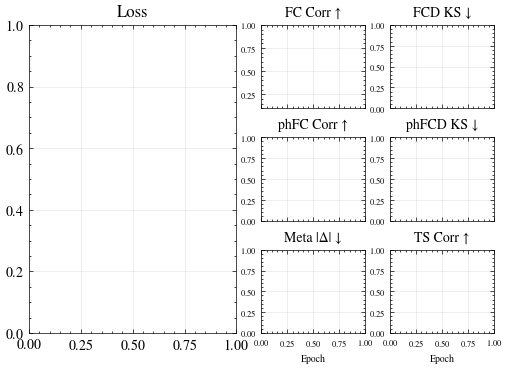

In [7]:
# ── Figure 3: loss plot plus 3x2 metrics grid (excludes TS PSD, Autocorr, FC MSE) ──
EXCLUDED_METRICS = {"fc_mse", "power_spectrum_distance", "autocorr_distance"}
other_metrics_filtered = [
    (mkey, mlabel) for (mkey, mlabel) in _EPOCH_METRICS[1:]
    if mkey not in EXCLUDED_METRICS
]

FC_MODEL_COLORS = {
    "Hopf": "#DD8452",        # salmon
    "Neural SDE": "#4C72B0",  # blue
    "Hybrid Hopf": "#55A868", # green
}

FIGSIZE_SPLIT_REDUCED = (6, 4)
fig3 = plt.figure(figsize=FIGSIZE_SPLIT_REDUCED)
gs = mgridspec.GridSpec(3, 3, figure=fig3, width_ratios=[2, 1, 1], hspace=0.35, wspace=0.18)

ax_loss = fig3.add_subplot(gs[:, 0])
has_data_loss, all_pos_loss = False, True
for ci, (label, store) in enumerate(model_stores.items()):
    val_vals = store.get_metric_history("loss", "val")
    if not val_vals:
        continue
    epochs = [e["epoch"] for e in store.val_metrics if "loss" in e]
    clean = [(ep, v) for ep, v in zip(epochs, val_vals) if v is not None and not math.isnan(v)]
    if not clean:
        continue
    ep_arr, v_arr = zip(*clean)
    color = FC_MODEL_COLORS.get(label)
    ax_loss.plot(ep_arr, v_arr, color=color, linewidth=0.8, alpha=0.25)
    ax_loss.plot(ep_arr, _smooth(list(v_arr), SMOOTH_WINDOW), label=label, color=color, linewidth=2.0)
    ax_loss.set_xlabel("Epoch", fontsize=7)
    has_data_loss = True
    if any(v <= 0 for v in v_arr):
        all_pos_loss = False

ax_loss.set_title("Loss", fontsize=12)
ax_loss.grid(True, alpha=0.3)
ax_loss.legend(fontsize=10)
if has_data_loss and all_pos_loss:
    ax_loss.set_yscale("log")

for idx, (mkey, mlabel) in enumerate(other_metrics_filtered):
    row, col = idx // 2, 1 + (idx % 2)
    ax = fig3.add_subplot(gs[row, col])
    has_data, all_pos = False, True
    for ci, (label, store) in enumerate(model_stores.items()):
        val_vals = store.get_metric_history(mkey, "val")
        if not val_vals:
            continue
        epochs = [e["epoch"] for e in store.val_metrics if mkey in e]
        clean = [(ep, v) for ep, v in zip(epochs, val_vals) if v is not None and not math.isnan(v)]
        if not clean:
            continue
        ep_arr, v_arr = zip(*clean)
        color = FC_MODEL_COLORS.get(label)
        ax.plot(ep_arr, v_arr, color=color, linewidth=0.8, alpha=0.25)
        ax.plot(ep_arr, _smooth(list(v_arr), SMOOTH_WINDOW), color=color, linewidth=1.5)
        has_data = True
        if any(v <= 0 for v in v_arr):
            all_pos = False
    if idx==0:
        ax.set_ylim(bottom=0.1)
    if row == 2:
        ax.set_xlabel("Epoch", fontsize=7)
    else:
        ax.set_xticklabels([])
    ax.set_title(mlabel, fontsize=10)
    ax.grid(True, alpha=0.3)
    if has_data and all_pos:
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
        ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis="y", which="major", labelsize=6)
    ax.tick_params(axis="x", which="major", labelsize=6)

plt.savefig(Path("paper_new/images") / DATASET_TYPE / "metrics_over_epochs_split_reduced.pdf", bbox_inches="tight", dpi=150)
plt.savefig(Path("paper_new/images_png") / DATASET_TYPE / "metrics_over_epochs_split_reduced.png", bbox_inches="tight", dpi=200)
plt.savefig(Path("paper_new/images_svg") / DATASET_TYPE / "metrics_over_epochs_split_reduced.svg", bbox_inches="tight")
plt.show()
